# =========================================
# FYP RANDOM FOREST - MULTI-COUNTRY
# Experiments:
# 1. RF MULTI CO2 Holdout
# 2. RF MULTI CO2 Rolling
# 3. RF MULTI Driver Holdout
# 4. RF MULTI Driver Rolling
# =========================================

# **MOUNT DRIVE**

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **IMPORT LIBRARIES**

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# **LOAD MULTI-COUNTRY DATASET**

In [40]:
path = "/content/drive/MyDrive/FYP_2026/DATA/FINAL_DATASETS/READY_FOR_TRAINING.csv"

df = pd.read_csv(path)
df = df.sort_values(["Country Code", "Year"]).reset_index(drop=True)

print("First year:", df["Year"].min())
print("Last year :", df["Year"].max())
print("Total rows:", len(df))

display(df.head())

First year: 1992
Last year : 2022
Total rows: 775


,Country Code,Year,GDP,Population,Energy_Use,CO2,Log_GDP,Log_Population,Log_Energy_Use,Log_CO2,Log_CO2_Lag1,Log_GDP_Lag1,Log_Energy_Lag1,Log_Pop_Lag1,Log_CO2_Lag2
0,ARG,1992,3.131202e+11,33693527.0,1407.276754,121514.170,26.469853,17.332816,7.250122,11.707794,11.676132,26.393473,7.234454,17.318973,11.627943
1,ARG,1993,3.388180e+11,34152717.0,1432.607503,118020.980,26.548729,17.346353,7.267949,11.678626,11.707794,26.469853,7.250122,17.332816,11.676132
2,ARG,1994,3.585921e+11,34613491.0,1530.527608,118506.770,26.605451,17.359754,7.334021,11.682734,11.678626,26.548729,7.267949,17.346353,11.707794
3,ARG,1995,3.483894e+11,35070020.0,1507.198475,125415.496,26.576587,17.372857,7.318671,11.739395,11.682734,26.605451,7.334021,17.359754,11.678626
4,ARG,1996,3.676438e+11,35513793.0,1534.091776,131445.544,26.630380,17.385432,7.336345,11.786356,11.739395,26.576587,7.318671,17.372857,11.682734


# **ENCODE COUNTRY**

In [41]:
encoder = LabelEncoder()
df["Country_ID"] = encoder.fit_transform(df["Country Code"])

display(df[["Country Code", "Country_ID"]].drop_duplicates().head())

,Country Code,Country_ID
0,ARG,0
31,BGD,1
62,BRA,2
93,CHL,3
124,CHN,4


# **OUTPUT PATHS**

In [42]:
metrics_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST"

forecast_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST"

visualization_dir = "/content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST"

os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(forecast_dir, exist_ok=True)
os.makedirs(visualization_dir, exist_ok=True)

print("Metrics dir:", metrics_dir)
print("Forecast dir:", forecast_dir)
print("Visualization dir:", visualization_dir)

Metrics dir: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST
Forecast dir: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST
Visualization dir: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST


# **MASTER SUMMARY COLLECTOR**

In [43]:
rf_multi_all_results = []

# =========================================
# RF - MULTI-COUNTRY - CO2 ONLY - HOLDOUT
# =========================================

# FEATURES & TARGET

In [44]:
features = [
    "Country_ID",
    "Year",
    "Log_CO2_Lag1",
    "Log_CO2_Lag2"
]

target = "Log_CO2"

# HOLDOUT SPLIT

In [45]:
train = df[df["Year"] <= 2019].copy()
test = df[(df["Year"] >= 2020) & (df["Year"] <= 2022)].copy()

print("Train years:", train["Year"].min(), "-", train["Year"].max())
print("Test years :", test["Year"].min(), "-", test["Year"].max())
print("Train rows :", len(train))
print("Test rows  :", len(test))

Train years: 1992 - 2019
Test years : 2020 - 2022
Train rows : 700
Test rows  : 75


# TRAIN MODEL & PREDICT

In [46]:
X_train = train[features]
y_train = train[target]

X_test = test[features]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

pred_log = model.predict(X_test)
pred_co2 = np.expm1(pred_log)

test["Pred_CO2"] = pred_co2
test["Actual_CO2"] = test["CO2"]

# PREDICTION TABLE

In [47]:
mys_pred = test[test["Country Code"] == "MYS"].copy()
mys_pred = mys_pred.sort_values("Year").reset_index(drop=True)

pred_df = mys_pred[["Year", "Actual_CO2", "Pred_CO2"]].copy()
display(pred_df)

,Year,Actual_CO2,Pred_CO2
0,2020,262158.82,282348.373784
1,2021,273332.16,278330.773717
2,2022,281883.80,279367.286077


# METRICS & RESULTS TABLE

In [48]:
rmse = np.sqrt(mean_squared_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"]))
mae = mean_absolute_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"])
mape = np.mean(
    np.abs((pred_df["Actual_CO2"] - pred_df["Pred_CO2"]) / pred_df["Actual_CO2"])
) * 100

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Scope": ["Multi-country"],
    "Variant": ["CO2-only"],
    "Validation": ["Holdout"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["1992-2019"],
    "Test_Period": ["2020-2022"],
    "RMSE": [rmse],
    "MAE": [mae],
    "MAPE": [mape]
})

display(rf_results)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,Random Forest,Multi-country,CO2-only,Holdout,Malaysia,1992-2019,2020-2022,12095.964388,9234.893808,3.474262


# SAVE PATHS

In [49]:
results_path = os.path.join(metrics_dir, "RF_MULTI_CO2_HOLDOUT_results.csv")

predictions_path = os.path.join(forecast_dir, "RF_MULTI_CO2_HOLDOUT_predictions.csv")

plot_path = os.path.join(visualization_dir, "RF_MULTI_CO2_HOLDOUT_plot.png")

# PLOT & SAVE

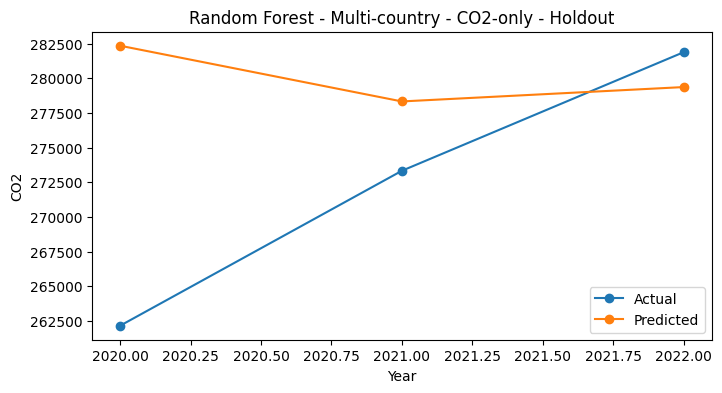

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(pred_df["Year"], pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(pred_df["Year"], pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("Random Forest - Multi-country - CO2-only - Holdout")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

# SAVE CSV

In [51]:
rf_results.to_csv(results_path, index=False)
pred_df.to_csv(predictions_path, index=False)

print("Saved results to:", results_path)
print("Saved predictions to:", predictions_path)
print("Saved plot to:", plot_path)

rf_multi_all_results.append(rf_results)

Saved results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST/RF_MULTI_CO2_HOLDOUT_results.csv
Saved predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST/RF_MULTI_CO2_HOLDOUT_predictions.csv
Saved plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST/RF_MULTI_CO2_HOLDOUT_plot.png


# =========================================
# RF - MULTI-COUNTRY - CO2 ONLY - ROLLING
# =========================================

# FEATURES & TARGET

In [52]:
features = [
    "Country_ID",
    "Year",
    "Log_CO2_Lag1",
    "Log_CO2_Lag2"
]

target = "Log_CO2"

# ROLLING PREDICTION

In [53]:
min_train = 8
results = []

years = sorted(df["Year"].unique())

for year in years[min_train:]:
    train = df[df["Year"] < year].copy()
    test = df[df["Year"] == year].copy()

    X_train = train[features]
    y_train = train[target]
    X_test = test[features]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_co2 = np.expm1(pred_log)

    test["Pred_CO2"] = pred_co2
    test["Actual_CO2"] = test["CO2"]
    test["Train_Start"] = train["Year"].min()
    test["Train_End"] = train["Year"].max()

    results.append(test.copy())

results_df = pd.concat(results, ignore_index=True)
display(results_df.head())

,Country Code,Year,GDP,Population,Energy_Use,CO2,Log_GDP,Log_Population,Log_Energy_Use,Log_CO2,Log_CO2_Lag1,Log_GDP_Lag1,Log_Energy_Lag1,Log_Pop_Lag1,Log_CO2_Lag2,Country_ID,Pred_CO2,Actual_CO2,Train_Start,Train_End
0,ARG,2000,3.956461e+11,3.721398e+07,1643.321320,143354.820,26.703786,17.432195,7.405083,11.873085,11.907300,26.711707,7.419272,17.420864,11.845865,0,1.400269e+05,143354.820,1992,1999
1,BGD,2000,8.349288e+10,1.345443e+08,135.945727,26539.266,25.148027,18.717404,4.919585,10.186418,10.130396,25.096448,4.911229,18.699131,10.052645,1,2.533466e+04,26539.266,1992,1999
2,BRA,2000,1.186419e+12,1.740183e+08,1081.361934,340182.820,27.801961,18.974671,6.986901,12.737241,12.698500,27.759017,6.996036,18.960919,12.667793,2,3.405608e+05,340182.820,1992,1999
3,CHL,2000,1.312437e+11,1.550364e+07,1623.480127,58502.620,25.600322,16.556585,7.392943,10.976844,11.025311,25.551802,7.399315,16.544625,10.955348,3,6.269377e+04,58502.620,1992,1999
4,CHN,2000,2.825096e+12,1.262645e+09,898.075004,3643809.500,28.669564,20.956475,6.801366,15.108541,15.082444,28.587187,6.781896,20.948595,15.026063,4,3.425488e+06,3643809.500,1992,1999


# PREDICTION TABLE

In [54]:
mys_pred = results_df[results_df["Country Code"] == "MYS"].copy()
mys_pred = mys_pred.sort_values("Year").reset_index(drop=True)

pred_df = mys_pred[["Year", "Actual_CO2", "Pred_CO2"]].copy()
display(pred_df)

,Year,Actual_CO2,Pred_CO2
0,2000,122881.384,105361.497265
1,2001,130890.050,129728.453157
2,2002,132035.230,136605.772328
3,2003,153384.340,136022.761405
4,2004,169674.400,160045.563765
5,2005,169978.320,177576.053202
6,2006,170166.450,169394.521645
7,2007,175454.450,171281.057840
8,2008,192847.060,183368.130632
9,2009,192122.740,203511.379175


# METRICS & RESULTS TABLE

In [55]:
rmse = np.sqrt(mean_squared_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"]))
mae = mean_absolute_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"])
mape = np.mean(
    np.abs((pred_df["Actual_CO2"] - pred_df["Pred_CO2"]) / pred_df["Actual_CO2"])
) * 100

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Scope": ["Multi-country"],
    "Variant": ["CO2-only"],
    "Validation": ["Rolling"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["Expanding window"],
    "Test_Period": ["Rolling 1-step ahead"],
    "RMSE": [rmse],
    "MAE": [mae],
    "MAPE": [mape]
})

display(rf_results)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,Random Forest,Multi-country,CO2-only,Rolling,Malaysia,Expanding window,Rolling 1-step ahead,13444.190994,11119.77803,5.362203


# SAVE PATHS

In [56]:
results_path = os.path.join(metrics_dir, "RF_MULTI_CO2_ROLLING_results.csv")

predictions_path = os.path.join(forecast_dir, "RF_MULTI_CO2_ROLLING_predictions.csv")

plot_path = os.path.join(visualization_dir, "RF_MULTI_CO2_ROLLING_plot.png")

# PLOT & SAVE

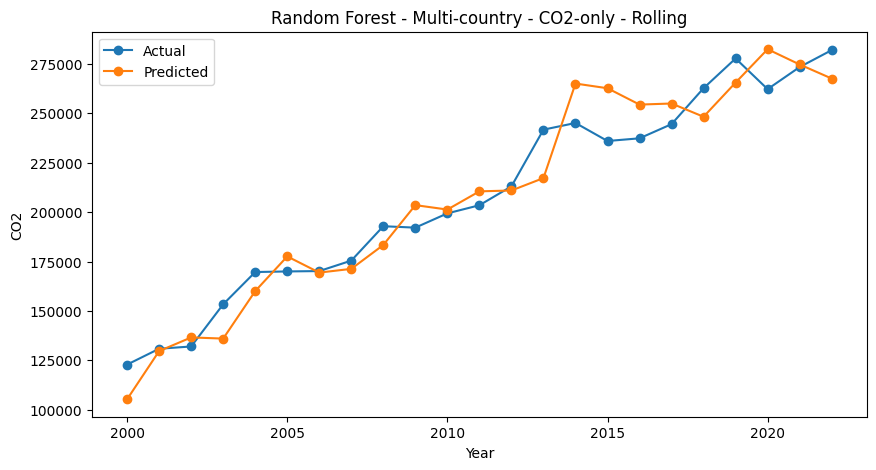

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(pred_df["Year"], pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(pred_df["Year"], pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("Random Forest - Multi-country - CO2-only - Rolling")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

# SAVE CSV

In [58]:
rf_results.to_csv(results_path, index=False)
pred_df.to_csv(predictions_path, index=False)

print("Saved results to:", results_path)
print("Saved predictions to:", predictions_path)
print("Saved plot to:", plot_path)

rf_multi_all_results.append(rf_results)

Saved results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST/RF_MULTI_CO2_ROLLING_results.csv
Saved predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST/RF_MULTI_CO2_ROLLING_predictions.csv
Saved plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST/RF_MULTI_CO2_ROLLING_plot.png


# =========================================
# RF - MULTI-COUNTRY - DRIVER-BASED - HOLDOUT
# =========================================

# FEATURES & TARGET

In [59]:
features = [
    "Country_ID",
    "Log_CO2_Lag1",
    "Log_CO2_Lag2",
    "Log_GDP_Lag1",
    "Log_Energy_Lag1",
    "Log_Pop_Lag1"
]

target = "Log_CO2"

# HOLDOUT SPLIT

In [60]:
train = df[df["Year"] <= 2019].copy()
test = df[(df["Year"] >= 2020) & (df["Year"] <= 2022)].copy()

print("Train years:", train["Year"].min(), "-", train["Year"].max())
print("Test years :", test["Year"].min(), "-", test["Year"].max())
print("Train rows :", len(train))
print("Test rows  :", len(test))

Train years: 1992 - 2019
Test years : 2020 - 2022
Train rows : 700
Test rows  : 75


# TRAIN MODEL & PREDICT

In [61]:
X_train = train[features]
y_train = train[target]

X_test = test[features]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

pred_log = model.predict(X_test)
pred_co2 = np.expm1(pred_log)

test["Pred_CO2"] = pred_co2
test["Actual_CO2"] = test["CO2"]

# PREDICTION TABLE

In [62]:
mys_pred = test[test["Country Code"] == "MYS"].copy()
mys_pred = mys_pred.sort_values("Year").reset_index(drop=True)

pred_df = mys_pred[["Year", "Actual_CO2", "Pred_CO2"]].copy()
display(pred_df)

,Year,Actual_CO2,Pred_CO2
0,2020,262158.82,281541.607815
1,2021,273332.16,277355.916238
2,2022,281883.80,279612.513161


# METRICS & RESULTS TABLE

In [63]:
rmse = np.sqrt(mean_squared_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"]))
mae = mean_absolute_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"])
mape = np.mean(
    np.abs((pred_df["Actual_CO2"] - pred_df["Pred_CO2"]) / pred_df["Actual_CO2"])
) * 100

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Scope": ["Multi-country"],
    "Variant": ["Driver-based"],
    "Validation": ["Holdout"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["1992-2019"],
    "Test_Period": ["2020-2022"],
    "RMSE": [rmse],
    "MAE": [mae],
    "MAPE": [mape]
})

display(rf_results)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,Random Forest,Multi-country,Driver-based,Holdout,Malaysia,1992-2019,2020-2022,11504.228522,8559.276964,3.223798


# SAVE PATHS

In [64]:
results_path = os.path.join(metrics_dir, "RF_MULTI_DRIVER_HOLDOUT_results.csv")
predictions_path = os.path.join(forecast_dir, "RF_MULTI_DRIVER_HOLDOUT_predictions.csv")
plot_path = os.path.join(visualization_dir, "RF_MULTI_DRIVER_HOLDOUT_plot.png")

# PLOT & SAVE

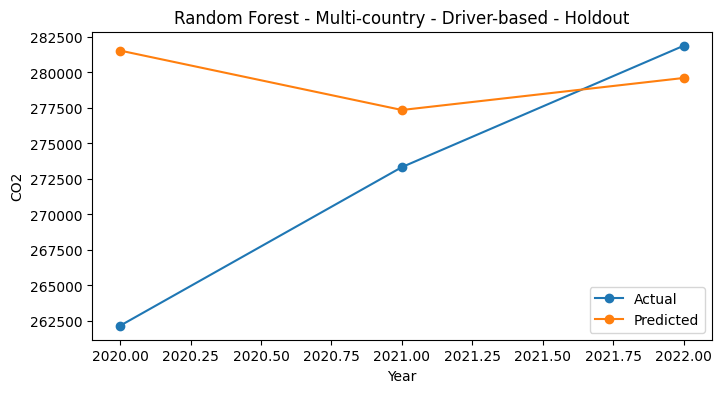

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(pred_df["Year"], pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(pred_df["Year"], pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("Random Forest - Multi-country - Driver-based - Holdout")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

# SAVE CSV

In [66]:
rf_results.to_csv(results_path, index=False)
pred_df.to_csv(predictions_path, index=False)

print("Saved results to:", results_path)
print("Saved predictions to:", predictions_path)
print("Saved plot to:", plot_path)

rf_multi_all_results.append(rf_results)

Saved results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST/RF_MULTI_DRIVER_HOLDOUT_results.csv
Saved predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST/RF_MULTI_DRIVER_HOLDOUT_predictions.csv
Saved plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST/RF_MULTI_DRIVER_HOLDOUT_plot.png


# =========================================
# RF - MULTI-COUNTRY - DRIVER-BASED - ROLLING
# =========================================

# FEATURES & TARGET

In [67]:
features = [
    "Country_ID",
    "Log_CO2_Lag1",
    "Log_CO2_Lag2",
    "Log_GDP_Lag1",
    "Log_Energy_Lag1",
    "Log_Pop_Lag1"
]

target = "Log_CO2"

# ROLLING 1-STEP

In [68]:
min_train = 8
results = []

years = sorted(df["Year"].unique())

for year in years[min_train:]:
    train = df[df["Year"] < year].copy()
    test = df[df["Year"] == year].copy()

    X_train = train[features]
    y_train = train[target]
    X_test = test[features]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_co2 = np.expm1(pred_log)

    test["Pred_CO2"] = pred_co2
    test["Actual_CO2"] = test["CO2"]
    test["Train_Start"] = train["Year"].min()
    test["Train_End"] = train["Year"].max()

    results.append(test.copy())

results_df = pd.concat(results, ignore_index=True)
display(results_df.head())

,Country Code,Year,GDP,Population,Energy_Use,CO2,Log_GDP,Log_Population,Log_Energy_Use,Log_CO2,Log_CO2_Lag1,Log_GDP_Lag1,Log_Energy_Lag1,Log_Pop_Lag1,Log_CO2_Lag2,Country_ID,Pred_CO2,Actual_CO2,Train_Start,Train_End
0,ARG,2000,3.956461e+11,3.721398e+07,1643.321320,143354.820,26.703786,17.432195,7.405083,11.873085,11.907300,26.711707,7.419272,17.420864,11.845865,0,1.488878e+05,143354.820,1992,1999
1,BGD,2000,8.349288e+10,1.345443e+08,135.945727,26539.266,25.148027,18.717404,4.919585,10.186418,10.130396,25.096448,4.911229,18.699131,10.052645,1,2.563934e+04,26539.266,1992,1999
2,BRA,2000,1.186419e+12,1.740183e+08,1081.361934,340182.820,27.801961,18.974671,6.986901,12.737241,12.698500,27.759017,6.996036,18.960919,12.667793,2,3.933169e+05,340182.820,1992,1999
3,CHL,2000,1.312437e+11,1.550364e+07,1623.480127,58502.620,25.600322,16.556585,7.392943,10.976844,11.025311,25.551802,7.399315,16.544625,10.955348,3,6.355006e+04,58502.620,1992,1999
4,CHN,2000,2.825096e+12,1.262645e+09,898.075004,3643809.500,28.669564,20.956475,6.801366,15.108541,15.082444,28.587187,6.781896,20.948595,15.026063,4,3.449887e+06,3643809.500,1992,1999


# PREDICTION TABLE

In [69]:
mys_pred = results_df[results_df["Country Code"] == "MYS"].copy()
mys_pred = mys_pred.sort_values("Year").reset_index(drop=True)

pred_df = mys_pred[["Year", "Actual_CO2", "Pred_CO2"]].copy()
display(pred_df)

,Year,Actual_CO2,Pred_CO2
0,2000,122881.384,107170.596285
1,2001,130890.050,123507.591247
2,2002,132035.230,137519.502743
3,2003,153384.340,136751.901395
4,2004,169674.400,162756.452795
5,2005,169978.320,173701.393090
6,2006,170166.450,170321.388484
7,2007,175454.450,170771.162370
8,2008,192847.060,181102.912849
9,2009,192122.740,201430.871936


# METRICS & RESULTS TABLE

In [70]:
rmse = np.sqrt(mean_squared_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"]))
mae = mean_absolute_error(pred_df["Actual_CO2"], pred_df["Pred_CO2"])
mape = np.mean(
    np.abs((pred_df["Actual_CO2"] - pred_df["Pred_CO2"]) / pred_df["Actual_CO2"])
) * 100

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Scope": ["Multi-country"],
    "Variant": ["Driver-based"],
    "Validation": ["Rolling"],
    "Target_Country": ["Malaysia"],
    "Train_Period": ["Expanding window"],
    "Test_Period": ["Rolling 1-step ahead"],
    "RMSE": [rmse],
    "MAE": [mae],
    "MAPE": [mape]
})

display(rf_results)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,Random Forest,Multi-country,Driver-based,Rolling,Malaysia,Expanding window,Rolling 1-step ahead,13727.134192,11282.560119,5.472408


# SAVE PATHS

In [71]:
results_path = os.path.join(metrics_dir, "RF_MULTI_DRIVER_ROLLING_results.csv")
predictions_path = os.path.join(forecast_dir, "RF_MULTI_DRIVER_ROLLING_predictions.csv")
plot_path = os.path.join(visualization_dir, "RF_MULTI_DRIVER_ROLLING_plot.png")

# PLOT & SAVE

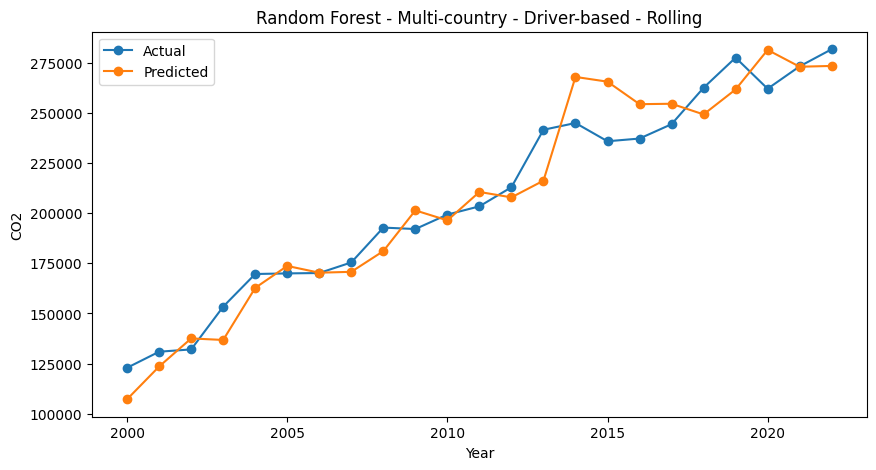

In [72]:
plt.figure(figsize=(10, 5))
plt.plot(pred_df["Year"], pred_df["Actual_CO2"], marker="o", label="Actual")
plt.plot(pred_df["Year"], pred_df["Pred_CO2"], marker="o", label="Predicted")

plt.title("Random Forest - Multi-country - Driver-based - Rolling")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

# SAVE CSV

In [73]:
rf_results.to_csv(results_path, index=False)
pred_df.to_csv(predictions_path, index=False)

print("Saved results to:", results_path)
print("Saved predictions to:", predictions_path)
print("Saved plot to:", plot_path)

rf_multi_all_results.append(rf_results)

Saved results to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST/RF_MULTI_DRIVER_ROLLING_results.csv
Saved predictions to: /content/drive/MyDrive/FYP_2026/RESULTS/FORECASTS/RANDOM_FOREST/RF_MULTI_DRIVER_ROLLING_predictions.csv
Saved plot to: /content/drive/MyDrive/FYP_2026/RESULTS/VISUALIZATIONS/RANDOM_FOREST/RF_MULTI_DRIVER_ROLLING_plot.png


# **COMBINED SUMMARY**

In [74]:
final_rf_multi_summary = pd.concat(rf_multi_all_results, ignore_index=True)
display(final_rf_multi_summary)

final_summary_path = os.path.join(metrics_dir, "RF_MULTI_ALL_RESULTS_SUMMARY.csv")
final_rf_multi_summary.to_csv(final_summary_path, index=False)

print("Saved final RF MULTI summary to:", final_summary_path)

,Model,Scope,Variant,Validation,Target_Country,Train_Period,Test_Period,RMSE,MAE,MAPE
0,Random Forest,Multi-country,CO2-only,Holdout,Malaysia,1992-2019,2020-2022,12095.964388,9234.893808,3.474262
1,Random Forest,Multi-country,CO2-only,Rolling,Malaysia,Expanding window,Rolling 1-step ahead,13444.190994,11119.778030,5.362203
2,Random Forest,Multi-country,Driver-based,Holdout,Malaysia,1992-2019,2020-2022,11504.228522,8559.276964,3.223798
3,Random Forest,Multi-country,Driver-based,Rolling,Malaysia,Expanding window,Rolling 1-step ahead,13727.134192,11282.560119,5.472408


Saved final RF MULTI summary to: /content/drive/MyDrive/FYP_2026/RESULTS/METRICS/RANDOM_FOREST/RF_MULTI_ALL_RESULTS_SUMMARY.csv
